In [1]:
#Data from NOAA - July 2024 :
#
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import xarray as xr
import numpy as np
from sklearn.linear_model import LinearRegression
import requests
import pandas as pd
from io import StringIO
import cmocean
import colorcet as cc

In [2]:
def dl_NOAA(url, sheet):
    response = requests.get(url)
    response.raise_for_status()

    with open('Sea_Ice_Index_Daily_Extent_G02135_v3.0.xlsx', 'wb') as file:
        file.write(response.content)

    df =  pd.read_excel('Sea_Ice_Index_Daily_Extent_G02135_v3.0.xlsx', sheet_name=sheet)
    ds = xr.Dataset(
    {
        'SIE': (['day_of_year', 'year'], df.iloc[1:, 2:49]),
        '1981-2010_mean': (['day_of_year'], df.iloc[1:, -2]),
        '1981-2010_median': (['day_of_year'], df.iloc[1:, -1])
    },
    coords={
        'day_of_year': range(1, 366),
        'year': range(1978, 2025)
    })
    return ds

In [3]:
# URL of the CSV file
url = 'https://noaadata.apps.nsidc.org/NOAA/G02135/seaice_analysis/Sea_Ice_Index_Daily_Extent_G02135_v3.0.xlsx'
sheet = 'SH-Daily-Extent'
ds_SH = dl_NOAA(url,sheet)
sheet = 'NH-Daily-Extent'
ds_NH = dl_NOAA(url,sheet)
ds = ds_SH+ds_NH

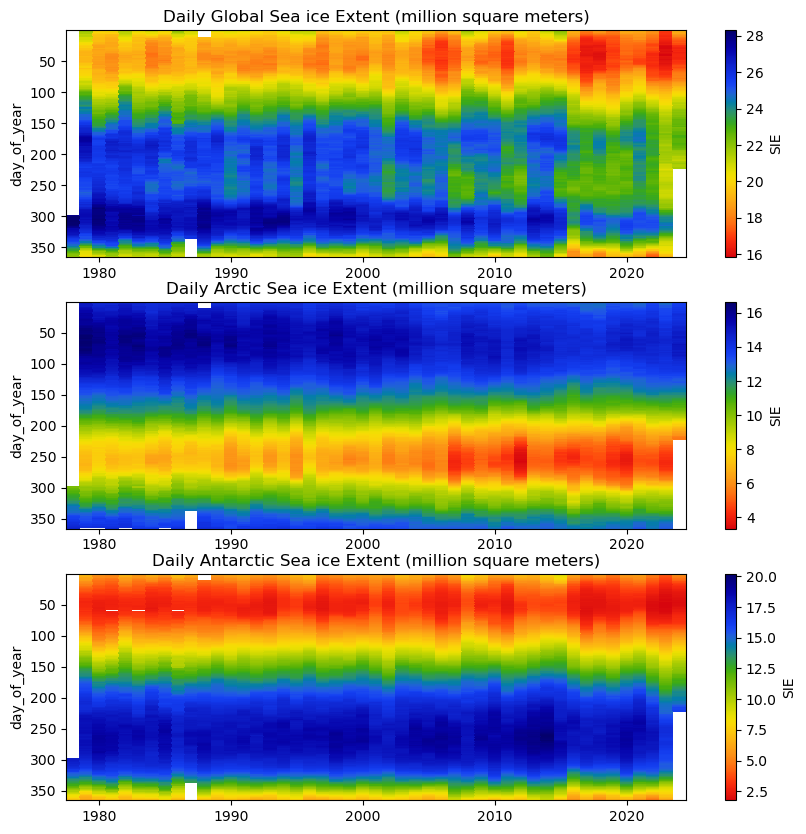

In [4]:
# Update the code to plot the same data in three subplots with different colorbars
mm = cc.cm.rainbow4_r
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10))

# Plotting the first subplot
ds['SIE'].plot(cmap=mm, ax=ax1)
ax1.invert_yaxis()
ax1.set_title('Daily Global Sea ice Extent (million square meters)')
ax1.set_xlabel('')

# Plotting the second subplot
ds_NH['SIE'].plot(cmap=mm, ax=ax2)
ax2.invert_yaxis()
ax2.set_title('Daily Arctic Sea ice Extent (million square meters)')
ax2.set_xlabel('')

# Plotting the third subplot
ds_SH['SIE'].plot(cmap=mm, ax=ax3)
ax3.invert_yaxis()
ax3.set_title('Daily Antarctic Sea ice Extent (million square meters)')
ax3.set_xlabel('')

plt.savefig('Figure/Global_SIE.png')

No handles with labels found to put in legend.


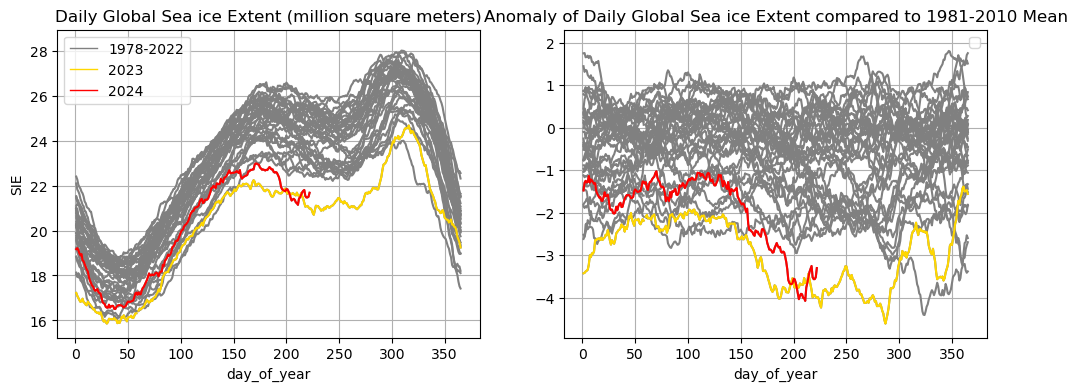

In [5]:
colors = ['grey', 'gold', 'red']
lines = [Line2D([0], [0], color=c, linewidth=1, linestyle='-') for c in colors]
labels = ['1978-2022', '2023', '2024']

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
# Plotting the SIE data for each year
ds['SIE'].plot.line(x='day_of_year', color='grey',ax = axs[0])
ds['SIE'].sel(year = 2023).plot.line(x='day_of_year', color='gold',ax = axs[0])
ds['SIE'].sel(year = 2024).plot.line(x='day_of_year', color='red',ax = axs[0])
axs[0].legend(lines, labels)
axs[0].set_title('Daily Global Sea ice Extent (million square meters)')
axs[0].grid()

# Plotting the anomaly of SIE compared to the variable 1981-2010_mean
anomaly = ds['SIE'] - ds['1981-2010_mean']
anomaly.plot.line(x='day_of_year', ax=axs[1], color='grey')
anomaly.sel(year = 2023).plot.line(x='day_of_year', color='gold',ax = axs[1])
anomaly.sel(year = 2024).plot.line(x='day_of_year', color='red',ax = axs[1])
axs[1].legend()
axs[1].set_title('Anomaly of Daily Global Sea ice Extent compared to 1981-2010 Mean')
axs[1].grid()

plt.savefig('Figure/Global_SIE_line.png')

No handles with labels found to put in legend.


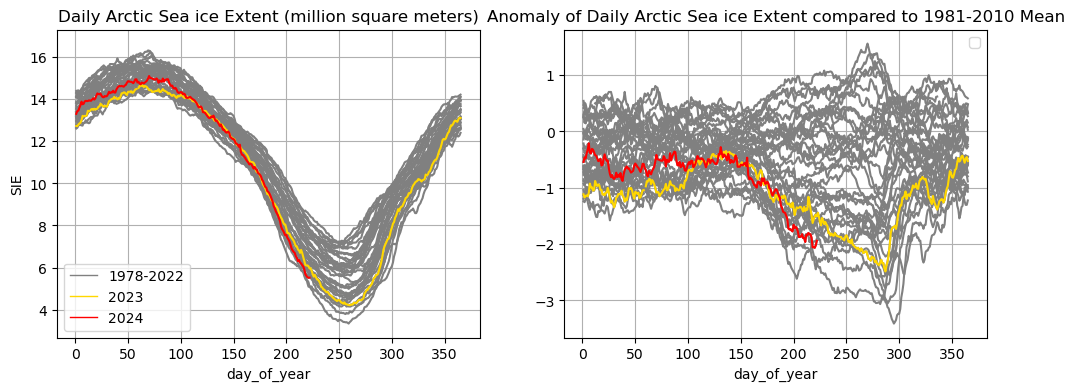

In [6]:
colors = ['grey', 'gold', 'red']
lines = [Line2D([0], [0], color=c, linewidth=1, linestyle='-') for c in colors]
labels = ['1978-2022', '2023', '2024']

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
# Plotting the SIE data for each year
ds_NH['SIE'].plot.line(x='day_of_year', color='grey',ax = axs[0])
ds_NH['SIE'].sel(year = 2023).plot.line(x='day_of_year', color='gold',ax = axs[0])
ds_NH['SIE'].sel(year = 2024).plot.line(x='day_of_year', color='red',ax = axs[0])
axs[0].legend(lines, labels)
axs[0].set_title('Daily Arctic Sea ice Extent (million square meters)')
axs[0].grid()

# Plotting the anomaly of SIE compared to the variable 1981-2010_mean
anomaly = ds_NH['SIE'] - ds_NH['1981-2010_mean']
anomaly.plot.line(x='day_of_year', ax=axs[1], color='grey')
anomaly.sel(year = 2023).plot.line(x='day_of_year', color='gold',ax = axs[1])
anomaly.sel(year = 2024).plot.line(x='day_of_year', color='red',ax = axs[1])
axs[1].legend()
axs[1].set_title('Anomaly of Daily Arctic Sea ice Extent compared to 1981-2010 Mean')
axs[1].grid()

plt.savefig('Figure/Arctic_SIE_line.png')

No handles with labels found to put in legend.


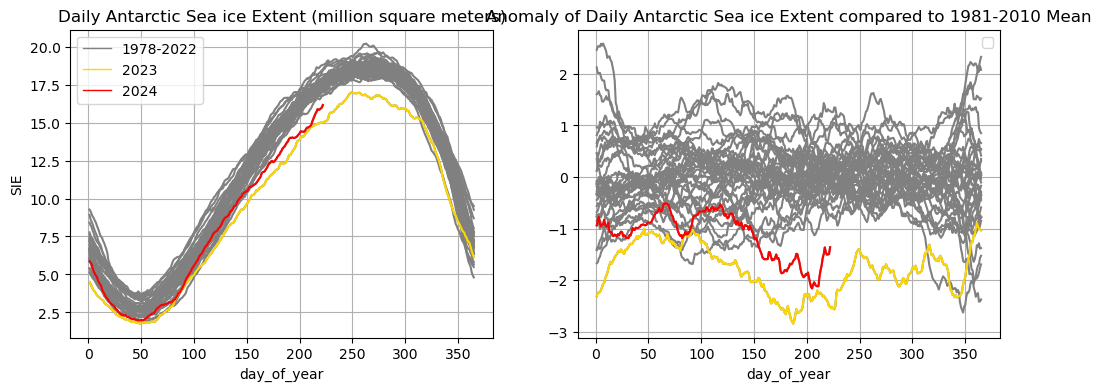

In [7]:
colors = ['grey', 'gold', 'red']
lines = [Line2D([0], [0], color=c, linewidth=1, linestyle='-') for c in colors]
labels = ['1978-2022', '2023', '2024']

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
# Plotting the SIE data for each year
ds_SH['SIE'].plot.line(x='day_of_year', color='grey',ax = axs[0])
ds_SH['SIE'].sel(year = 2023).plot.line(x='day_of_year', color='gold',ax = axs[0])
ds_SH['SIE'].sel(year = 2024).plot.line(x='day_of_year', color='red',ax = axs[0])
axs[0].legend(lines, labels)
axs[0].set_title('Daily Antarctic Sea ice Extent (million square meters)')
axs[0].grid()

# Plotting the anomaly of SIE compared to the variable 1981-2010_mean
anomaly = ds_SH['SIE'] - ds_SH['1981-2010_mean']
anomaly.plot.line(x='day_of_year', ax=axs[1], color='grey')
anomaly.sel(year = 2023).plot.line(x='day_of_year', color='gold',ax = axs[1])
anomaly.sel(year = 2024).plot.line(x='day_of_year', color='red',ax = axs[1])
axs[1].legend()
axs[1].set_title('Anomaly of Daily Antarctic Sea ice Extent compared to 1981-2010 Mean')
axs[1].grid()

plt.savefig('Figure/Antarctic_SIE_line.png')